# Q5: Enhancing K-Means Clustering with Association Rule Mining

## Approach: Semi-Supervised Rule-Guided Feature Weighting + Class-Stratified Pattern Features

**Problem:** Standard K-Means uses equal weights for all features and ignores any available label structure. However, not all features are equally discriminative for price-range classification. Association rule mining can reveal which features (and feature combinations) are most strongly associated with specific classes.

**Method (two-pronged, semi-supervised):**
1. **Feature Weighting via Rule Frequency:** Mine association rules *per class* (each `price_range` group). Features that appear frequently in high-confidence rules for specific classes are more discriminative. Weight each original feature by how often its discretized levels appear in class-specific rules. This step is explicitly label-guided.
2. **Class-Stratified Pattern Features:** Mine a small set of high-lift patterns per class. Create binary features indicating whether each sample matches class-specific patterns. This injects class-discriminative structural information without overwhelming the original feature space.

**Note:** This approach is semi-supervised — it uses true labels during feature engineering (rule mining) but not during clustering itself (K-Means remains unsupervised). The label information is used only to *guide* which features and patterns are most relevant.

**Inspiration:** This approach is inspired by the *pattern-based feature weighting* idea from data mining literature, where frequent pattern mining identifies task-relevant features for downstream tasks. Specifically:
- The feature weighting component draws from the concept of **TF-IDF-style feature importance**, adapted to use association rule lift as a proxy for discriminative power (analogous to how IDF captures term specificity).
- The class-stratified mining is motivated by **supervised discretization** techniques (e.g., Fayyad & Irani, 1993), where class labels guide the binning process to maximize class separability.
- The overall framework resembles **feature augmentation for clustering** as discussed in lecture, where auxiliary information (here: association rules) enriches the feature space before applying standard clustering algorithms.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             adjusted_rand_score, normalized_mutual_info_score)
from scipy.optimize import linear_sum_assignment
from mlxtend.frequent_patterns import fpgrowth, association_rules

# Load data
df = pd.read_csv('data/mobile_price.csv')
X = df.drop('price_range', axis=1).values
y = df['price_range'].values
feature_names = df.drop('price_range', axis=1).columns.tolist()

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

seeds = [0, 10, 42, 100, 999]
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features, 4 classes")

Dataset: 2000 samples, 20 features, 4 classes


## Evaluation Utilities

In [2]:
def hungarian_mapping(y_true, y_pred, n_classes=4):
    """Map cluster IDs to true labels using Hungarian algorithm for optimal assignment."""
    cost_matrix = np.zeros((n_classes, n_classes))
    for i in range(n_classes):
        for j in range(n_classes):
            cost_matrix[i, j] = -np.sum((y_pred == i) & (y_true == j))
    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    mapping = dict(zip(row_ind, col_ind))
    return np.array([mapping[c] for c in y_pred])


def evaluate_clustering(y_true, cluster_labels, n_classes=4):
    """Evaluate clustering as classification after Hungarian mapping, plus ARI and NMI."""
    y_mapped = hungarian_mapping(y_true, cluster_labels, n_classes)
    return {
        'accuracy': accuracy_score(y_true, y_mapped),
        'precision': precision_score(y_true, y_mapped, average='macro'),
        'recall': recall_score(y_true, y_mapped, average='macro'),
        'f1': f1_score(y_true, y_mapped, average='macro'),
        'ARI': adjusted_rand_score(y_true, cluster_labels),
        'NMI': normalized_mutual_info_score(y_true, cluster_labels),
    }


def run_kmeans_evaluation(X_input, y_true, seeds, method_name):
    """Run K-Means across multiple seeds and return per-seed + average metrics."""
    all_results = []
    for seed in seeds:
        km = KMeans(n_clusters=4, random_state=seed, n_init=10)
        clusters = km.fit_predict(X_input)
        metrics = evaluate_clustering(y_true, clusters)
        metrics['seed'] = seed
        metrics['method'] = method_name
        all_results.append(metrics)
    return pd.DataFrame(all_results)

## Baseline: Original K-Means

In [3]:
baseline_results = run_kmeans_evaluation(X_scaled, y, seeds, 'Baseline K-Means')
print("=== Baseline K-Means (per seed) ===")
print(baseline_results.to_string(index=False))
print(f"\n=== Baseline Average ===")
print(baseline_results[['accuracy', 'precision', 'recall', 'f1']].mean())

=== Baseline K-Means (per seed) ===
 accuracy  precision  recall       f1      ARI      NMI  seed           method
   0.2945   0.294042  0.2945 0.292637 0.005263 0.007146     0 Baseline K-Means
   0.2955   0.295336  0.2955 0.293648 0.005610 0.007544    10 Baseline K-Means
   0.2970   0.296623  0.2970 0.295035 0.005962 0.007902    42 Baseline K-Means
   0.2955   0.294995  0.2955 0.293510 0.005520 0.007423   100 Baseline K-Means
   0.2985   0.298367  0.2985 0.295579 0.006834 0.009012   999 Baseline K-Means

=== Baseline Average ===
accuracy     0.296200
precision    0.295873
recall       0.296200
f1           0.294082
dtype: float64


## Step 1: Discretize features and mine class-stratified association rules

In [4]:
def discretize_343(series, name):
    """Discretize using 3:4:3 value range split."""
    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val
    if range_val == 0:
        return pd.Series(f'{name}_medium', index=series.index)
    low_upper = min_val + 0.3 * range_val
    med_upper = min_val + 0.7 * range_val
    result = pd.Series(index=series.index, dtype=str)
    result[series <= low_upper] = f'{name}_low'
    result[(series > low_upper) & (series <= med_upper)] = f'{name}_medium'
    result[series > med_upper] = f'{name}_high'
    return result

# Discretize all features for the full dataset
df_features = df.drop('price_range', axis=1)
disc_df = pd.DataFrame(index=df.index)
for feat in feature_names:
    disc_df[feat] = discretize_343(df_features[feat], feat)

# Build one-hot transaction matrix for the full dataset
transactions_full = pd.get_dummies(disc_df).astype(bool)
print(f"Full transaction matrix: {transactions_full.shape}")

# Mine class-stratified rules: for each price_range class, mine its own rules
class_rules = {}
feature_importance = np.zeros(len(feature_names))  # accumulate importance

for cls in range(4):
    cls_mask = y == cls
    cls_transactions = transactions_full[cls_mask]
    
    # Mine frequent itemsets within this class
    freq = fpgrowth(cls_transactions, min_support=0.3, use_colnames=True)
    if len(freq) == 0:
        print(f"  Class {cls}: no frequent itemsets found")
        class_rules[cls] = pd.DataFrame()
        continue
    
    # Generate rules
    rules = association_rules(freq, metric='confidence', min_threshold=0.5, 
                              num_itemsets=len(cls_transactions))
    rules = rules[rules['lift'] >= 1.0]
    class_rules[cls] = rules
    
    print(f"  Class {cls}: {len(freq)} frequent itemsets, {len(rules)} rules")
    
    # Accumulate feature importance: count how many times each original feature 
    # appears in the antecedents/consequents of high-confidence rules
    for _, rule in rules.iterrows():
        all_items = set(rule['antecedents']) | set(rule['consequents'])
        lift = rule['lift']
        for item in all_items:
            # Extract original feature name from item like 'ram_high'
            for fi, fname in enumerate(feature_names):
                if item.startswith(fname + '_'):
                    feature_importance[fi] += lift  # weight by lift
                    break

print(f"\nFeature importance (weighted by lift):")
for fi, fname in enumerate(feature_names):
    if feature_importance[fi] > 0:
        print(f"  {fname}: {feature_importance[fi]:.2f}")

Full transaction matrix: (2000, 54)
  Class 0: 143 frequent itemsets, 167 rules
  Class 1: 98 frequent itemsets, 80 rules


  Class 2: 95 frequent itemsets, 64 rules
  Class 3: 125 frequent itemsets, 125 rules

Feature importance (weighted by lift):
  battery_power: 3.14
  blue: 43.78
  clock_speed: 8.32
  dual_sim: 51.28
  fc: 193.09
  four_g: 118.57
  int_memory: 3.03
  m_dep: 5.14
  mobile_wt: 5.10
  n_cores: 3.06
  pc: 13.99
  px_height: 54.23
  px_width: 10.02
  ram: 295.34
  sc_h: 2.02
  sc_w: 40.81
  talk_time: 3.01
  three_g: 259.75
  touch_screen: 43.06
  wifi: 37.69


## Step 2: Compute feature weights and select class-specific patterns

In [5]:
# Step 2a: Derive feature weights from rule importance
# Normalize importance to create weights (minimum weight = 1.0)
weights = feature_importance.copy()
if weights.max() > 0:
    weights = 1.0 + (weights / weights.max()) * 2.0  # scale to [1.0, 3.0]
else:
    weights = np.ones(len(feature_names))

print("Feature weights derived from association rules:")
for fi, fname in enumerate(feature_names):
    print(f"  {fname}: {weights[fi]:.3f}")

# Apply weights to standardized features
X_weighted = X_scaled * weights[np.newaxis, :]

# Step 2b: Select top class-specific patterns (small set per class)
selected_patterns = []
pattern_labels = []  # which class this pattern is associated with

for cls in range(4):
    rules = class_rules[cls]
    if len(rules) == 0:
        continue
    
    # Select top patterns by lift * confidence (most discriminative)
    rules_sorted = rules.copy()
    rules_sorted['score'] = rules_sorted['lift'] * rules_sorted['confidence']
    rules_sorted = rules_sorted.sort_values('score', ascending=False)
    
    seen = set()
    count = 0
    for _, rule in rules_sorted.iterrows():
        pattern = frozenset(rule['antecedents'] | rule['consequents'])
        if len(pattern) >= 2 and pattern not in seen:
            seen.add(pattern)
            selected_patterns.append(pattern)
            pattern_labels.append(cls)
            count += 1
            if count >= 5:  # top 5 patterns per class
                break

print(f"\nSelected {len(selected_patterns)} class-specific patterns total")
for i, (p, cls) in enumerate(zip(selected_patterns, pattern_labels)):
    print(f"  Class {cls}: {set(p)}")

Feature weights derived from association rules:
  battery_power: 1.021
  blue: 1.296
  clock_speed: 1.056
  dual_sim: 1.347
  fc: 2.308
  four_g: 1.803
  int_memory: 1.021
  m_dep: 1.035
  mobile_wt: 1.035
  n_cores: 1.021
  pc: 1.095
  px_height: 1.367
  px_width: 1.068
  ram: 3.000
  sc_h: 1.014
  sc_w: 1.276
  talk_time: 1.020
  three_g: 2.759
  touch_screen: 1.292
  wifi: 1.255

Selected 20 class-specific patterns total
  Class 0: {'pc_pc_low', 'fc_fc_low'}
  Class 0: {'pc_pc_low', 'ram_ram_low', 'fc_fc_low'}
  Class 0: {'px_height_px_height_low', 'three_g_three_g_high', 'four_g_four_g_high'}
  Class 0: {'three_g_three_g_high', 'four_g_four_g_high'}
  Class 0: {'three_g_three_g_high', 'ram_ram_low', 'fc_fc_low', 'four_g_four_g_high'}
  Class 1: {'pc_pc_low', 'fc_fc_low'}
  Class 1: {'three_g_three_g_high', 'ram_ram_medium', 'four_g_four_g_high'}
  Class 1: {'three_g_three_g_high', 'four_g_four_g_high'}
  Class 1: {'three_g_three_g_high', 'fc_fc_low', 'four_g_four_g_high'}
  Class 1

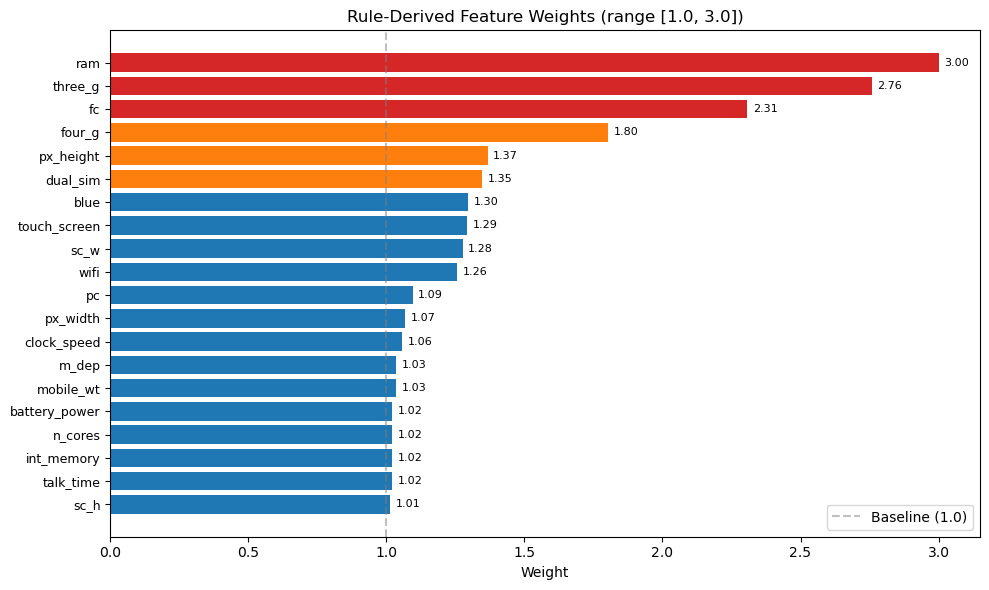

In [6]:
# Feature-weight bar chart (sorted by weight)
sorted_idx = np.argsort(weights)[::-1]
sorted_names = [feature_names[i] for i in sorted_idx]
sorted_weights = weights[sorted_idx]

fig, ax = plt.subplots(figsize=(10, 6))
colors_feat = ['#d62728' if w > 2.0 else '#ff7f0e' if w > 1.3 else '#1f77b4' for w in sorted_weights]
bars = ax.barh(range(len(sorted_names)), sorted_weights, color=colors_feat)
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names, fontsize=9)
ax.set_xlabel('Weight')
ax.set_title('Rule-Derived Feature Weights (range [1.0, 3.0])')
ax.invert_yaxis()
ax.axvline(x=1.0, color='gray', linestyle='--', alpha=0.5, label='Baseline (1.0)')
for i, v in enumerate(sorted_weights):
    ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('report/figures/q5_feature_weights.png', dpi=150, bbox_inches='tight')
plt.show()

## Sanity check: label-free global rule weighting

In [7]:
# Sanity check: mine association rules on all samples without using price_range labels.
# If this performs much worse than class-stratified weighting, the gain is due to label-guided rules,
# not merely because any association-rule-derived weights help K-Means.
global_freq = fpgrowth(transactions_full, min_support=0.3, use_colnames=True)
global_rules = association_rules(global_freq, metric='confidence', min_threshold=0.5,
                                 num_itemsets=len(transactions_full))
global_rules = global_rules[global_rules['lift'] >= 1.0]

global_importance = np.zeros(len(feature_names))
for _, rule in global_rules.iterrows():
    all_items = set(rule['antecedents']) | set(rule['consequents'])
    lift = rule['lift']
    for item in all_items:
        for fi, fname in enumerate(feature_names):
            if item.startswith(fname + '_'):
                global_importance[fi] += lift
                break

if global_importance.max() > 0:
    global_weights = 1.0 + 2.0 * (global_importance / global_importance.max())
else:
    global_weights = np.ones(len(feature_names))

X_global_weighted = X_scaled * global_weights

print(f'Global frequent itemsets: {len(global_freq)}, global rules: {len(global_rules)}')
print('Top label-free feature weights:')
for idx in np.argsort(global_weights)[::-1][:8]:
    print(f'  {feature_names[idx]:<15} weight={global_weights[idx]:.2f}  importance={global_importance[idx]:.2f}')


Global frequent itemsets: 72, global rules: 39
Top label-free feature weights:
  three_g         weight=3.00  importance=26.85
  fc              weight=2.69  importance=22.66
  four_g          weight=1.80  importance=10.71
  px_height       weight=1.38  importance=5.04
  blue            weight=1.30  importance=4.05
  touch_screen    weight=1.30  importance=4.02
  sc_w            weight=1.30  importance=4.01
  dual_sim        weight=1.23  importance=3.05


## Step 3: Build augmented feature matrix

In [8]:
# Create binary features for selected patterns
rule_features = np.zeros((len(X), len(selected_patterns)))
for idx, pattern in enumerate(selected_patterns):
    mask = np.ones(len(X), dtype=bool)
    for item in pattern:
        if item in transactions_full.columns:
            mask &= transactions_full[item].values
        else:
            mask[:] = False
    rule_features[:, idx] = mask.astype(float)

print(f"Rule features shape: {rule_features.shape}")
print(f"Non-zero rule features per sample (mean): {rule_features.sum(axis=1).mean():.1f}")

# Scale rule features
rule_scaler = StandardScaler()
rule_features_scaled = rule_scaler.fit_transform(rule_features)

# Combine: weighted original features + pattern features
X_augmented = np.hstack([X_weighted, rule_features_scaled])
print(f"Augmented feature matrix: {X_augmented.shape} (weighted originals + {len(selected_patterns)} pattern features)")

Rule features shape: (2000, 20)
Non-zero rule features per sample (mean): 6.0
Augmented feature matrix: (2000, 40) (weighted originals + 20 pattern features)


## Step 4: Ablation Study + Full Comparison

We compare 4 variants to understand which component contributes most:
1. **Baseline**: Standard K-Means on standardized features
2. **Weighting-only**: K-Means on rule-weighted features (no pattern features)
3. **Pattern-only**: K-Means on standardized features + pattern features (no weighting)
4. **Full method**: K-Means on weighted features + pattern features

In [9]:
# Ablation: weighting-only (no pattern features)
weighting_results = run_kmeans_evaluation(X_weighted, y, seeds, 'Weighting-only')

# Sanity check: rule-derived weights mined globally without labels
global_weighting_results = run_kmeans_evaluation(X_global_weighted, y, seeds, 'Global-rule weighting')

# Ablation: pattern-only (unweighted original + pattern features)
X_pattern_only = np.hstack([X_scaled, rule_features_scaled])
pattern_results = run_kmeans_evaluation(X_pattern_only, y, seeds, 'Pattern-only')

# Full method: weighted + pattern features
improved_results = run_kmeans_evaluation(X_augmented, y, seeds, 'Full Method')

# Combine all results
all_results = pd.concat([baseline_results, global_weighting_results, weighting_results, pattern_results, improved_results], ignore_index=True)

# Per-seed comparison
print("=== Per-Seed Comparison ===")
for seed in seeds:
    print(f"\nSeed {seed}:")
    seed_data = all_results[all_results['seed'] == seed]
    for _, row in seed_data.iterrows():
        print(f"  {row['method']:<18} Acc={row['accuracy']:.4f}  F1={row['f1']:.4f}  ARI={row['ARI']:.4f}  NMI={row['NMI']:.4f}")

# Average performance
print("\n=== Average Performance ===")
metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'ARI', 'NMI']
avg = all_results.groupby('method')[metrics_cols].mean()
avg = avg.reindex(['Baseline K-Means', 'Global-rule weighting', 'Weighting-only', 'Pattern-only', 'Full Method'])
print(avg.round(4))

=== Per-Seed Comparison ===

Seed 0:
  Baseline K-Means   Acc=0.2945  F1=0.2926  ARI=0.0053  NMI=0.0071
  Global-rule weighting Acc=0.2660  F1=0.2606  ARI=0.0008  NMI=0.0025
  Weighting-only     Acc=0.4415  F1=0.4280  ARI=0.1762  NMI=0.2103
  Pattern-only       Acc=0.2620  F1=0.2539  ARI=-0.0005  NMI=0.0013
  Full Method        Acc=0.3885  F1=0.3962  ARI=0.1002  NMI=0.1511

Seed 10:
  Baseline K-Means   Acc=0.2955  F1=0.2936  ARI=0.0056  NMI=0.0075
  Global-rule weighting Acc=0.2660  F1=0.2606  ARI=0.0008  NMI=0.0024
  Weighting-only     Acc=0.4415  F1=0.4280  ARI=0.1758  NMI=0.2098
  Pattern-only       Acc=0.2620  F1=0.2539  ARI=-0.0005  NMI=0.0013
  Full Method        Acc=0.3905  F1=0.3957  ARI=0.1035  NMI=0.1550

Seed 42:
  Baseline K-Means   Acc=0.2970  F1=0.2950  ARI=0.0060  NMI=0.0079
  Global-rule weighting Acc=0.2660  F1=0.2606  ARI=0.0008  NMI=0.0024
  Weighting-only     Acc=0.4425  F1=0.4286  ARI=0.1778  NMI=0.2116
  Pattern-only       Acc=0.2620  F1=0.2539  ARI=-0.0005  NMI=

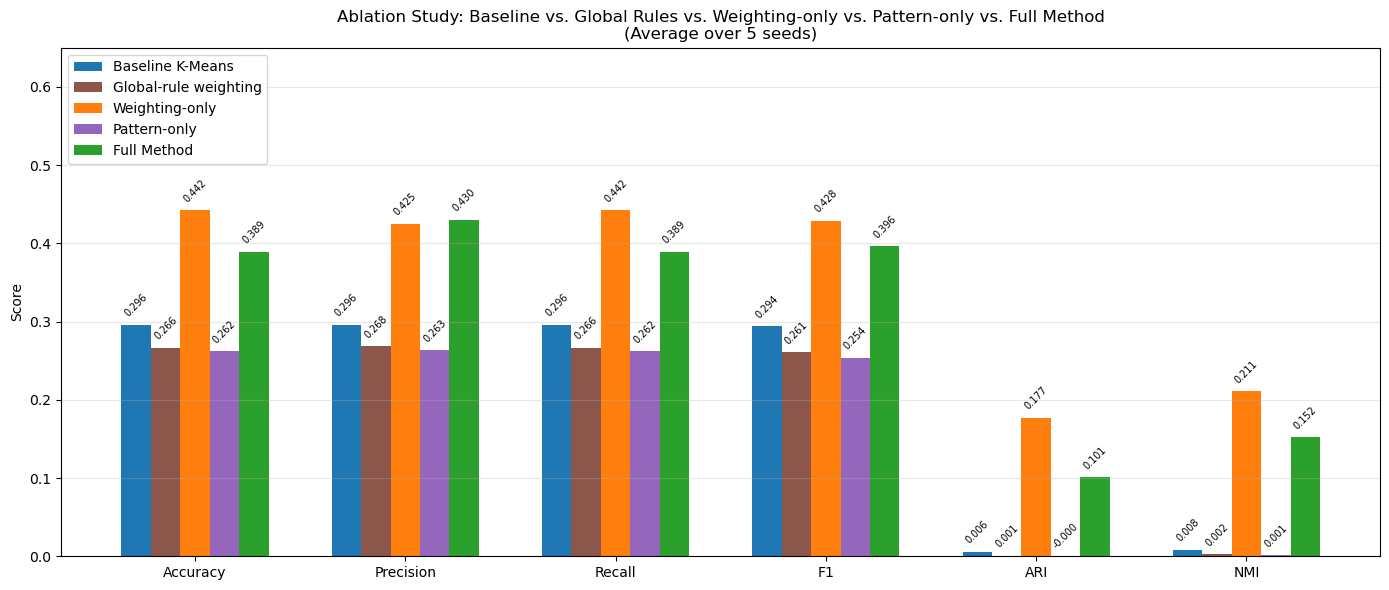

In [10]:
# Visualization: ablation bar chart
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'ARI', 'NMI']
methods = ['Baseline K-Means', 'Global-rule weighting', 'Weighting-only', 'Pattern-only', 'Full Method']
colors_bar = ['#1f77b4', '#8c564b', '#ff7f0e', '#9467bd', '#2ca02c']

avg_data = all_results.groupby('method')[metrics_list].mean().reindex(methods)

x = np.arange(len(metrics_list))
width = 0.14

fig, ax = plt.subplots(figsize=(14, 6))
for i, (method, color) in enumerate(zip(methods, colors_bar)):
    bars = ax.bar(x + (i - (len(methods) - 1) / 2) * width, avg_data.loc[method], width, 
                  label=method, color=color)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.008, f'{h:.3f}',
                ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_ylabel('Score')
ax.set_title('Ablation Study: Baseline vs. Global Rules vs. Weighting-only vs. Pattern-only vs. Full Method\n(Average over 5 seeds)')
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1', 'ARI', 'NMI'])
ax.legend(loc='upper left')
ax.set_ylim(0, 0.65)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('report/figures/q5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Save results
all_results.to_csv('results/q5_comparison.csv', index=False)

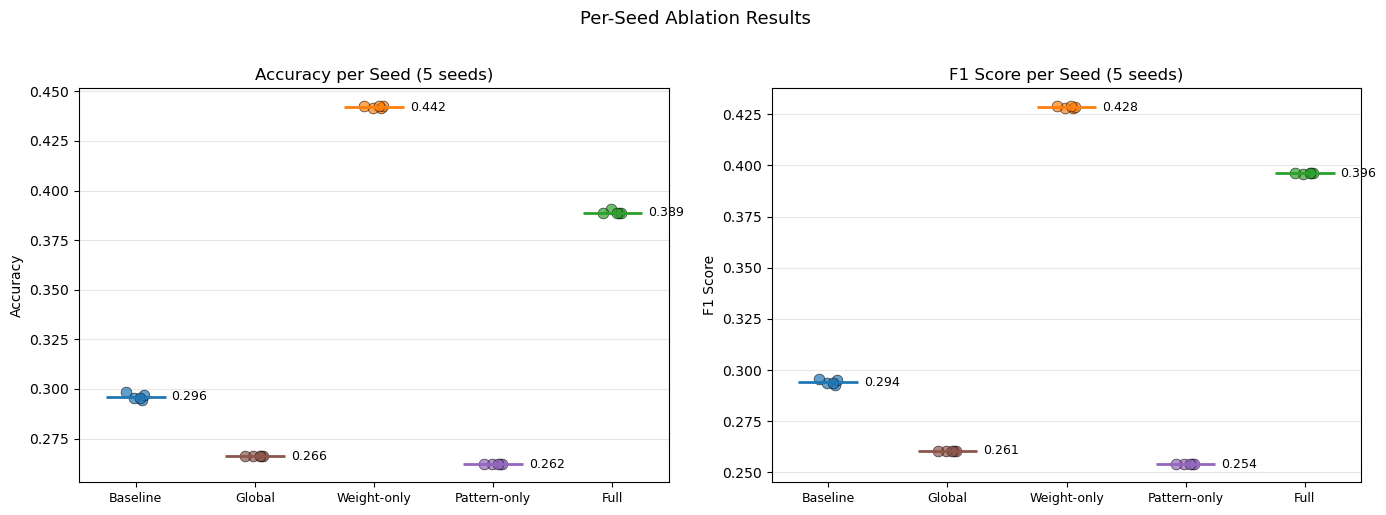

In [11]:
# Per-seed performance dot plot (Accuracy and F1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
methods_order = ['Baseline K-Means', 'Global-rule weighting', 'Weighting-only', 'Pattern-only', 'Full Method']
colors_dot = {'Baseline K-Means': '#1f77b4', 'Global-rule weighting': '#8c564b',
              'Weighting-only': '#ff7f0e', 'Pattern-only': '#9467bd', 'Full Method': '#2ca02c'}

for ax, metric, title in zip(axes, ['accuracy', 'f1'], ['Accuracy', 'F1 Score']):
    for i, method in enumerate(methods_order):
        method_data = all_results[all_results['method'] == method]
        vals = method_data[metric].values
        jitter = np.random.default_rng(42).uniform(-0.1, 0.1, len(vals))
        ax.scatter([i] * len(vals) + jitter, vals, c=colors_dot[method], 
                   s=60, alpha=0.7, edgecolors='black', linewidths=0.5, zorder=3)
        mean_val = vals.mean()
        ax.hlines(mean_val, i - 0.25, i + 0.25, colors=colors_dot[method], 
                  linewidths=2, zorder=4)
        ax.text(i + 0.3, mean_val, f'{mean_val:.3f}', va='center', fontsize=9)
    
    ax.set_xticks(range(len(methods_order)))
    ax.set_xticklabels(['Baseline', 'Global', 'Weight-only', 'Pattern-only', 'Full'], fontsize=9)
    ax.set_ylabel(title)
    ax.set_title(f'{title} per Seed (5 seeds)')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Per-Seed Ablation Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('report/figures/q5_per_seed.png', dpi=150, bbox_inches='tight')
plt.show()